# Figure 2: Dual occluder task

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-02-13 16:52:45,133::INFO::settings.py::Setting loglevel to INFO
2025-02-13 16:52:45,134::INFO::settings.py::Setting stores to {}
2025-02-13 16:52:45,134::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-13 16:52:45,135::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-13 16:52:45,135::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-13 16:52:45,136::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-13 16:52:45,136::INFO::settings.py::Setting database.user to celia
2025-02-13 16:52:45,137::INFO::settings.py::Setting database.password to celia_mathislab
2025-02-13 16:52:45,299::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-13 16:52:45,404::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:45,860::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:45,860::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:46,423::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:46,423::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:46,566::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:46,566::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:46,883::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:46,883::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:47,199::INFO::table.py::could not log event in table ~log
2025-02-13 16:52:47,199::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [5]:
# add sessions to groups table for easily pulling sessions
dual_occuder = [{"dataset": "Nightingale_2024-08-14_1"},
                {"dataset": "Nightingale_2024-08-13_1"},
                {"dataset": "Nightingale_2024-08-12_1"},
                {"dataset": "Nightingale_2024-08-11_1"},
                {"dataset": "Nightingale_2024-08-10_1"},
                {"dataset": "Lemming_2024-08-13_1"},
                {"dataset": "Lemming_2024-08-12_1"},
                {"dataset": "Lemming_2024-08-11_1"},
                {"dataset": "Lemming_2024-08-10_1"},
                {"dataset": "Jacana_2024-08-13_1"},
                {"dataset": "Jacana_2024-08-14_1"},
                {"dataset": "Jacana_2024-08-15_1"},
                {"dataset": "Jacana_2024-08-16_1"},
                {"dataset": "Jacana_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-10_2"},
                {"dataset": "Kiwi_2024-08-11_4"},
                {"dataset": "Kiwi_2024-08-12_2"},
                {"dataset": "Kiwi_2024-08-13_1"},
                {"dataset": "Kiwi_2024-08-14_1"},
                {"dataset": "Oribi_2024-08-16_1"},
                {"dataset": "Oribi_2024-08-19_1"},
                {"dataset": "Oribi_2024-08-20_1"},
                {"dataset": "Oribi_2024-08-21_1"},
                {"dataset": "Oribi_2024-08-22_1"},
                {"dataset": "Pheasant_2024-08-15_2"},
                {"dataset": "Pheasant_2024-08-16_1"},
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]

print(len(dual_occuder))

28


## Example trajectories (Pheasant_2024-08-15_2)

In [6]:
# Load dataset and box positions
df = DataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"}, columns=["dataset", "reward", "x", "y", "trial", "aperture", "iti", "trial_left_choice", "trial_duration", "trial_tortuosity"])
box_df = base_analysis.BoxDataFrame().get_data(key=dual_occuder[-1])

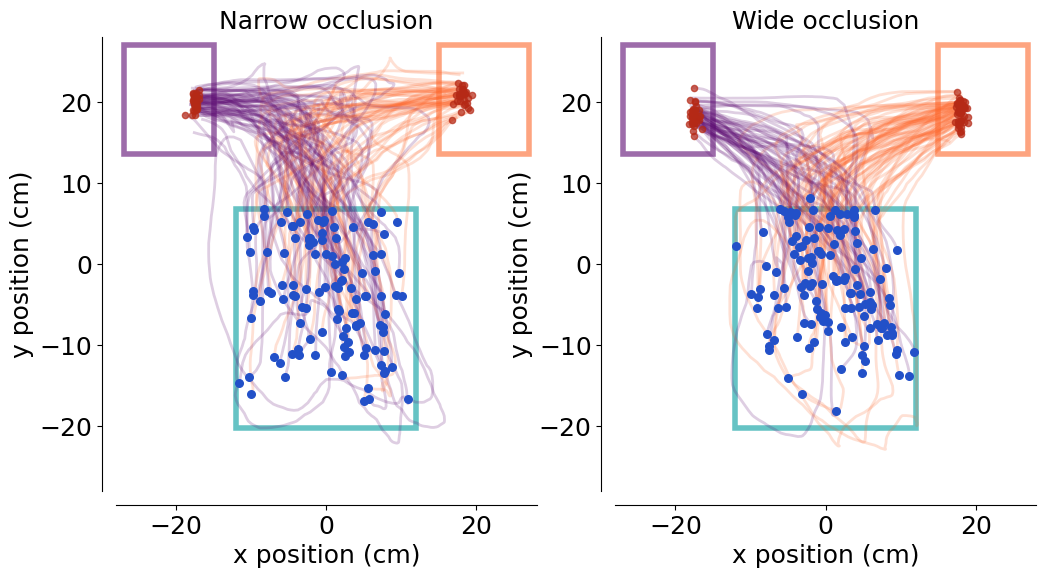

In [7]:
df = df [df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(df)

ax = plotting.plot_session(
    df=j_shaped,
    box_df=box_df,
    per_aperture=True,
    per_side=True,
)

ax[0].set_title("Narrow occlusion")
ax[1].set_title("Wide occlusion")

sns.despine(offset=10)
#plt.savefig(save_fig_path + "example_session_trajectory_plot_dual_occluder_figure_2.svg", transparent=True)

## All sessions

In [8]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle"])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = df.join(offline_kinematics_df)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    big_df ["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1)
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [9]:
dual_occuder = [{"dataset": d} for d in (vr4mice.Groups() * vr4mice.Labels & 'label="dual_occluder_paper"').fetch("dataset")]

In [ ]:
dfs = []
dual = (vr4mice.Dataset() & f'session_label = "ar_discrim_occluders"') & (vr4mice.Collab() & 'idx=3')
dual_list = [{"dataset": x["dataset"]}for x in dual]
if {"dataset": 'J731_2024-12-11_1'} in dual_list:
    dual_list.remove({"dataset": 'J731_2024-12-11_1'})
if {"dataset": 'J731_2024-12-12_1'} in dual_list:
    dual_list.remove({"dataset": 'J731_2024-12-12_1'})
if {"dataset": 'J731_2024-12-13_1'} in dual_list:
    dual_list.remove({"dataset": 'J731_2024-12-13_1'})
print(dual_list)
big_df = get_all_in_list(data_set_list = dual_list, training_stage="ar_discrim_occluders")

In [ ]:
big_df = get_all_in_list(data_set_list=dual_occuder, training_stage="dual_occluder")

In [9]:
big_df.to_pickle("big_df_contrast_dual_niell.pkl")

In [10]:
niell_data = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_dual.pkl")

big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

2025-02-13 16:53:20,779::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:20,779::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:20,787::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:20,787::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:20,879::INFO::category.py::Using categorical un

              mean       sem
aperture                    
12.0      0.842619  0.016433
4.3       0.767836  0.015315


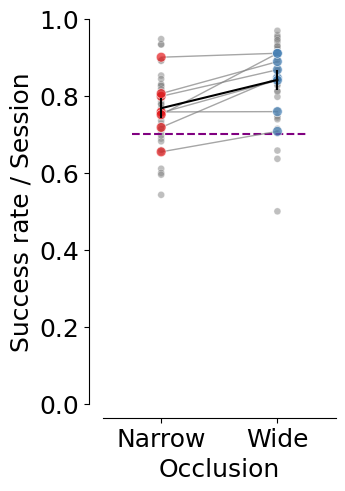

In [11]:
# Success rate per mouse (new)
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True
)
ax.set_ylim(0, 1)
ax.set_ylabel("Success rate")
ax.hlines(0.7, xmin=-0.25, xmax=len(big_df.aperture.unique())-0.75, linestyles="dashed", colors="purple")
plt.ylim(0,1.0)
plt.xlim(-0.5,1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Occlusion")
ax.set_xticks([0,1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([],[], frameon=False)
plt.savefig(save_fig_path + "reward_success.svg", transparent=True)


2025-02-13 16:53:23,168::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:23,168::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:23,176::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:23,176::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:23,217::INFO::category.py::Using categorical un

wide occlusion mean:  0.5018219866287107 std:  0.05216854047984742
narrow occlusion mean:  0.4981780133712893 std:  0.052168540479847425


TtestResult(statistic=0.2152922007006244, pvalue=0.8306908723542814, df=38)

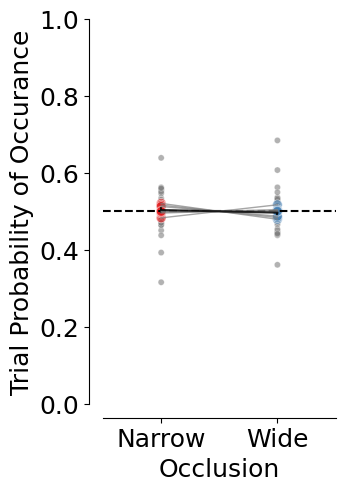

In [12]:
# Occurance of the different conditions
counts = big_df.groupby(["dataset", "mouse_name", "aperture"]).trial.nunique().reset_index(name="trial_count")
total_trials = big_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
    
counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts ["aperture"] = counts.aperture.astype("str")
    
fig,ax = plt.subplots(1,1, figsize = (3,5))

sns.lineplot(data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(), 
             x="aperture", 
             y="probability", 
             units="mouse_name", 
             estimator=None, 
             ax=ax,
             color="grey", 
             alpha=0.7,
             linewidth=1,
             zorder=3)

sns.scatterplot(data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(), 
                x="aperture", 
                y="probability", 
                hue="aperture", 
                ax=ax,
                palette = plotting.colors_aperture, 
                alpha=0.6,
                s=50,
                zorder=2)

sns.scatterplot(data=counts, 
                x="aperture", 
                y="probability", 
                hue="aperture", 
                ax=ax,
                palette = ["grey"] * counts["dataset"].nunique(), 
                alpha=0.6, 
                zorder=1,
                s=20)

sns.lineplot(data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(), 
             x="aperture", 
             y="probability", 
             ax=ax,
             color="black", 
             err_style="bars",
             errorbar="se",  
             alpha=0.8, 
             zorder=4)

ax.axhline(0.5, linestyle="dashed", color="black", alpha=1)

plt.ylim(0,1)
plt.xlim(-0.5,1.5)
plt.xticks([0,1], ["Narrow", "Wide"])

plt.xlabel("Occlusion")
plt.ylabel("Trial Probability of Occurance")
sns.despine(offset=10)
plt.legend([],[], frameon=False)

plt.savefig(save_fig_path + "dual_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index = "dataset", columns=["aperture"], values=["probability"]) 
print("wide occlusion mean: ", np.mean(np.array(counts ["probability"] ["12.0"])), "std: ",  np.std(np.array(counts ["probability"] ["12.0"])))
print("narrow occlusion mean: ", np.mean(np.array(counts ["probability"] ["4.3"])),  "std: ",  np.std(np.array(counts ["probability"] ["4.3"])))
ttest_rel(np.array(counts ["probability"] ["12.0"]),np.array(counts ["probability"] ["4.3"]))

2025-02-13 16:53:25,970::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:25,970::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:25,981::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:25,981::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 16:53:26,054::INFO::category.py::Using categorical un

              mean       sem
aperture                    
12.0      0.511282  0.019762
4.3       0.571254  0.022119


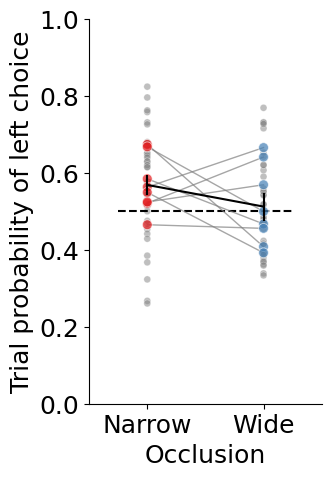

In [ ]:
# Trial probability of left choice
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True
)

ax.set_xlim(-0.5,1.5)
ax.set_xticks([0,1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
ax.set_ylim(0, 1)
plt.legend([],[], frameon=False)
ax.set_ylabel("Trial probability of left choice")
ax.hlines(0.5, xmin=-0.25, xmax=len(big_df.aperture.unique())-0.75, linestyles="dashed", colors="k")

## Mean trajectory plots

In [14]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df[big_df.iti == 0.0]
j_shaped =  analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 18, 20], label="y")
# [6.75, 20, 30]
mean_mouse = j_shaped.groupby(
    ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

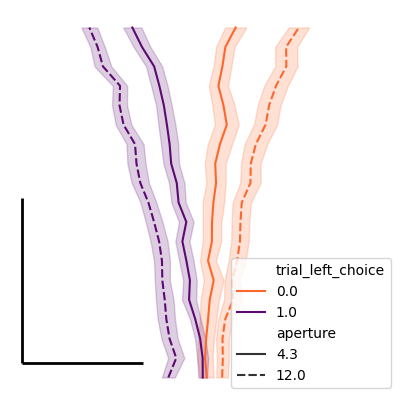

In [15]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis('off')
ax.legend(loc="lower right")
plt.savefig(save_fig_path + "mean_trajectory.svg", transparent =True)

In [16]:
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped ["x_flipped"] = j_shaped["x"]*j_shaped.flip_one_side
mean_mouse = j_shaped.groupby(
    ["dataset", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

In [17]:
print(AnovaRM(data=mean_mouse, depvar='x_flipped', 
              subject='dataset', within=['aperture', "bin_centers"]).fit())

                       Anova
                     F Value  Num DF  Den DF  Pr > F
----------------------------------------------------
aperture             91.9714  1.0000  38.0000 0.0000
bin_centers          96.6648 18.0000 684.0000 0.0000
aperture:bin_centers 10.4768 18.0000 684.0000 0.0000



**Interpretation**

Since all p-values are very small (0.0000), we can conclude that both aperture and bin_centers significantly influence x_flipped, and their interaction is also significant. This means that the effect of aperture on x_flipped depends on bin_centers.

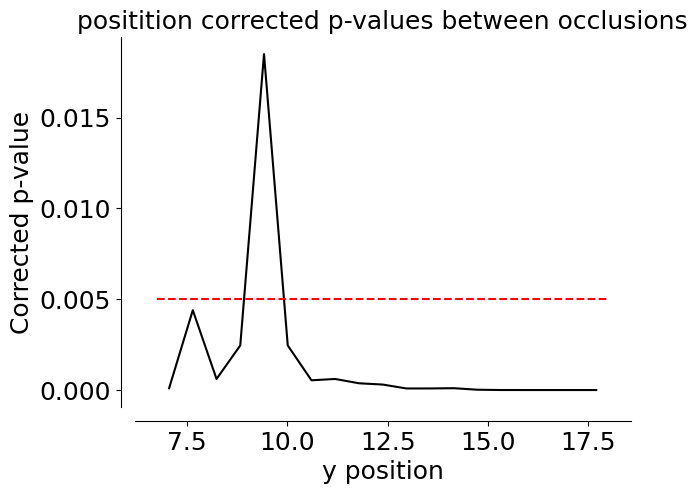

In [18]:
p_values = []
for i in mean_mouse.bin_centers.unique():
    section = mean_mouse[mean_mouse.bin_centers==i]
    t= ttest_ind(section[section.aperture==section.aperture.unique()[0]].x_flipped, 
                 section[section.aperture==section.aperture.unique()[1]].x_flipped)
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df ["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.005, xmin=6.75, xmax=18, color="red", linestyle="dashed")

plt.xlabel("y position")
plt.ylabel("Corrected p-value")
plt.title("positition corrected p-values between occlusions")

sns.despine(offset=10)

In [19]:
from scipy.stats import ttest_rel

# Get unique bin centers
bin_centers = mean_mouse['bin_centers'].unique()
aperture_levels = mean_mouse['aperture'].unique()

if len(aperture_levels) != 2:
    raise ValueError("This test assumes exactly 2 aperture levels.")

# Loop through each bin center and compare apertures
results = []
for bin_center in bin_centers:
    subset = mean_mouse[mean_mouse['bin_centers'] == bin_center]
    
    x1 = subset[subset['aperture'] == aperture_levels[0]]['x_flipped']
    x2 = subset[subset['aperture'] == aperture_levels[1]]['x_flipped']
    
    if len(x1) == len(x2):  # Ensure paired samples
        t_stat, p_val = ttest_rel(x1, x2)
        results.append((bin_center, t_stat, p_val))
    else:
        print(f"Skipping bin center {bin_center} due to mismatched sample sizes.")

# Print results
for bin_center, t_stat, p_val in results:
    print(f"Bin Center {bin_center}: t = {t_stat:.3f}, p = {p_val:.5f}")


Bin Center 7.045999999999999: t = -5.945, p = 0.00000
Bin Center 7.638: t = -3.738, p = 0.00061
Bin Center 8.23: t = -4.854, p = 0.00002
Bin Center 8.822: t = -3.961, p = 0.00032
Bin Center 9.4145: t = -2.882, p = 0.00646
Bin Center 10.007000000000001: t = -5.001, p = 0.00001
Bin Center 10.599: t = -6.305, p = 0.00000
Bin Center 11.190999999999999: t = -7.510, p = 0.00000
Bin Center 11.783000000000001: t = -7.577, p = 0.00000
Bin Center 12.375: t = -7.283, p = 0.00000
Bin Center 12.966999999999999: t = -7.472, p = 0.00000
Bin Center 13.559000000000001: t = -8.826, p = 0.00000
Bin Center 14.151: t = -8.230, p = 0.00000
Bin Center 14.742999999999999: t = -9.356, p = 0.00000
Bin Center 15.3355: t = -10.325, p = 0.00000
Bin Center 15.928: t = -9.563, p = 0.00000
Bin Center 16.52: t = -10.666, p = 0.00000
Bin Center 17.112000000000002: t = -10.323, p = 0.00000
Bin Center 17.704: t = -9.460, p = 0.00000


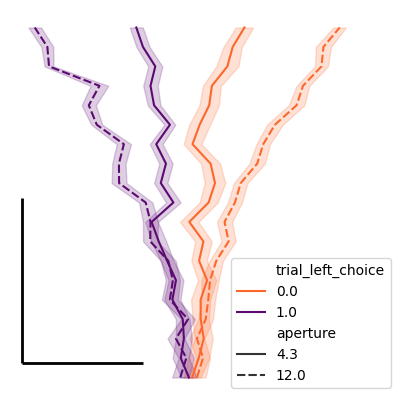

In [20]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=j_shaped[j_shaped.dataset =="Pheasant_2024-08-15_2"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis('off')

ax.legend(loc="lower right")
plt.savefig(save_fig_path + "example_session_mean_trajectory.svg", transparent =True)

In [21]:
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=100) # 100 to run anova

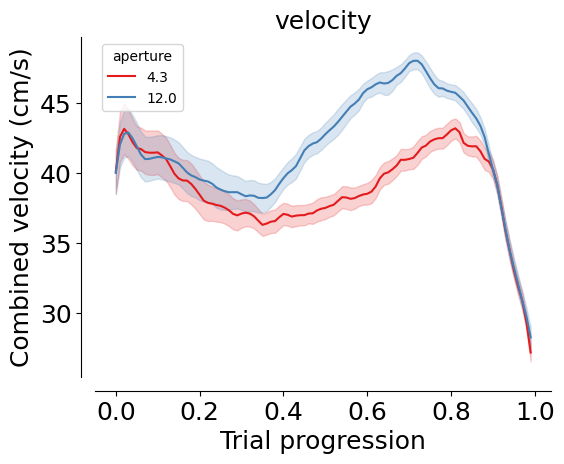

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y="velocity",
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else plotting.colors_aperture[:2]
        ),
        hue="aperture",
        errorbar="se",
        ax=ax,
    )
ax.set_title(f"{label}")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "mean_veloctiy.svg", transparent =True)

In [23]:
print(AnovaRM(data=mean_mouse, depvar='velocity', 
              subject='dataset', within=['aperture', "trial_length"]).fit()) 

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              35.8967  1.0000   38.0000 0.0000
trial_length          27.9150 99.0000 3762.0000 0.0000
aperture:trial_length 20.2458 99.0000 3762.0000 0.0000



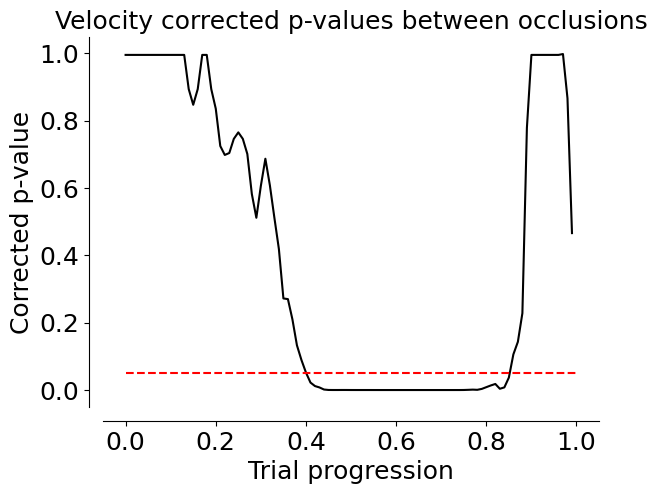

In [27]:
p_values = []
for i in mean_mouse.trial_length.unique():
    section = mean_mouse [mean_mouse.trial_length==i]
    t= ttest_ind(section [section.aperture==section.aperture.unique()[0]].velocity, section [section.aperture==section.aperture.unique()[1]].velocity)
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df ["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")
plt.title("Velocity corrected p-values between occlusions")

sns.despine(offset=10)

## Optimal p of an L-p curve

In [28]:
big_df["optimal_p"] = analysis.get_optimal_p(big_df)
j_shaped = analysis.get_jshaped_trials(big_df)

2025-02-13 17:03:26,530::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:03:26,530::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:03:26,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:03:26,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:03:26,626::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-5.015098200727714, pvalue=1.26647195655486e-05, df=38)


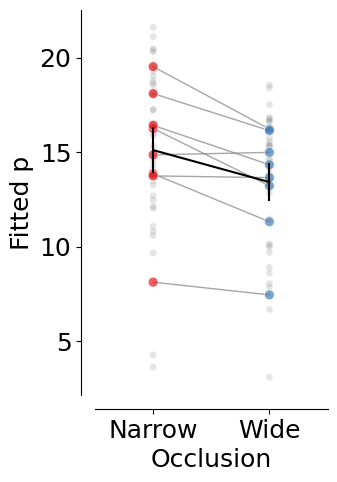

In [29]:
fig,ax = plt.subplots(1,1, figsize = (3,5))

counts = j_shaped[j_shaped.trial_rewarded==1].groupby(["mouse_name", "dataset", "aperture"], as_index=False).optimal_p.mean()

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_xlim(-0.5,1.5)
ax.set_xticks([0,1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
plt.legend([],[], frameon=False)
ax.set_ylabel("Fitted p")

sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")